# 🌲 Entrenamiento de Random Forest para Predicción de Abandono Estudiantil

## Descripción del Notebook

Este notebook implementa un entrenamiento **clásico de Machine Learning** (sin aprendizaje federado) utilizando el algoritmo **Random Forest** sobre el dataset de abandono estudiantil (`students_dropout.csv`).

### Objetivos:
1. Cargar y preprocesar el dataset de estudiantes
2. Entrenar un modelo Random Forest clásico
3. Evaluar el modelo mediante métricas de clasificación:
   - Matriz de Confusión
   - Accuracy (Precisión Global)
   - F1-Score (Macro y por clase)
   - Precision (Precisión por clase)
   - Recall (Sensibilidad por clase)

### Dataset
**Fuente:** `data/students_dropout.csv`  
**Variable objetivo:** `Target` (Dropout, Graduate, Enrolled)

---

## 📦 1. Importación de Librerías

Se importan todas las dependencias necesarias para:
- Carga y manipulación de datos (pandas, numpy)
- Preprocesamiento (sklearn)
- Visualización (matplotlib, seaborn)
- Modelo Random Forest (sklearn.ensemble)
- Métricas de evaluación (sklearn.metrics)

In [24]:
from src.infrastructure.dataset.dataset_factory import DatasetFactory
# ============================================================================
# LIBRERÍAS PARA MANIPULACIÓN DE DATOS
# ============================================================================
import pandas as pd
import numpy as np

# ============================================================================
# LIBRERÍAS PARA VISUALIZACIÓN
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# LIBRERÍAS PARA PREPROCESAMIENTO Y MÉTRICAS
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# ============================================================================
# MODELO RANDOM FOREST - SKLEARN
# ============================================================================
from sklearn.ensemble import RandomForestClassifier

# ============================================================================
# CONFIGURACIÓN DE VISUALIZACIÓN
# ============================================================================
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Ignorar warnings para una salida más limpia
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas las librerías importadas correctamente")

✅ Todas las librerías importadas correctamente


## 📊 2. Carga y Exploración del Dataset

En esta sección cargamos el dataset y realizamos un análisis exploratorio inicial para comprender:
- La estructura de los datos
- Tipos de variables
- Distribución de la variable objetivo
- Valores nulos o faltantes

In [25]:
# ============================================================================
# CARGA DEL DATASET
# ============================================================================
# El dataset utiliza punto y coma (;) como separador
df = pd.read_csv(
    '../../../data/students_dropout.csv',
    sep=';',
    encoding='utf-8'
)

print(f"✅ Dataset cargado exitosamente")
print(f"📊 Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

✅ Dataset cargado exitosamente
📊 Dimensiones: 4424 filas × 37 columnas


In [26]:
# ============================================================================
# VISUALIZACIÓN DE LAS PRIMERAS FILAS
# ============================================================================
# Mostramos las primeras 5 filas para entender la estructura
print("📋 Primeras 5 filas del dataset:")
df.head()

📋 Primeras 5 filas del dataset:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [27]:
# ============================================================================
# INFORMACIÓN GENERAL DEL DATASET
# ============================================================================
# Tipos de datos y valores no nulos por columna
print("=" * 80)
print("📝 INFORMACIÓN DEL DATASET")
print("=" * 80)
df.info()

📝 INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualif

In [28]:
# ============================================================================
# ESTADÍSTICAS DESCRIPTIVAS
# ============================================================================
# Resumen estadístico de variables numéricas
print("=" * 80)
print("📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 80)
df.describe()

📈 ESTADÍSTICAS DESCRIPTIVAS


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [29]:
# ============================================================================
# VERIFICACIÓN DE VALORES NULOS
# ============================================================================
# Contamos valores nulos por columna
print("🔍 Valores nulos por columna:")
null_counts = df.isnull().sum()
null_counts[null_counts > 0] if null_counts.sum() > 0 else print("✅ No hay valores nulos en el dataset")

🔍 Valores nulos por columna:
✅ No hay valores nulos en el dataset


## 🎯 3. Análisis de la Variable Objetivo

La variable `Target` indica el estado final del estudiante:
- **Dropout**: Abandono del curso
- **Graduate**: Graduación exitosa
- **Enrolled**: Continúa matriculado

Es crucial analizar su distribución para detectar posibles desbalanceos de clases.

🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Target)
          Cantidad  Porcentaje (%)
Target                            
Graduate      2209       49.932188
Dropout       1421       32.120253
Enrolled       794       17.947559


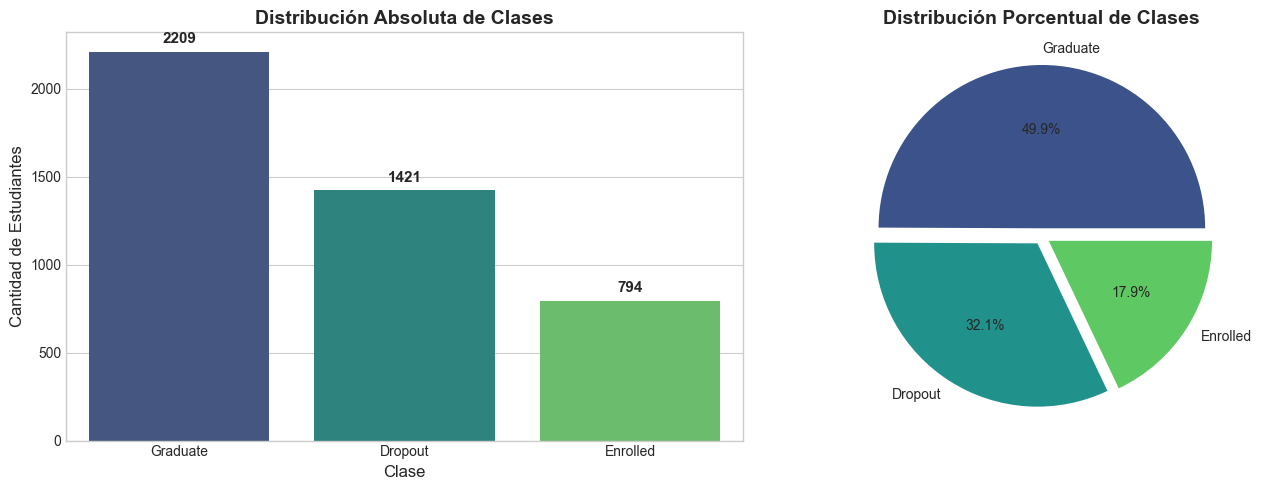


⚠️ Nota: El desbalanceo de clases puede afectar el rendimiento del modelo.
   Se recomienda usar métricas como F1-Score y no solo Accuracy.


In [30]:
# ============================================================================
# DISTRIBUCIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
print("=" * 80)
print("🎯 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Target)")
print("=" * 80)
target_counts = df['Target'].value_counts()
target_pct = df['Target'].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame({
    'Cantidad': target_counts,
    'Porcentaje (%)': target_pct
})
print(distribution_df)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribución Absoluta de Clases', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Cantidad de Estudiantes', fontsize=12)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11, fontweight='bold')

# Gráfico de torta
axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('viridis', len(target_counts)),
    explode=[0.05] * len(target_counts)
)
axes[1].set_title('Distribución Porcentual de Clases', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n⚠️ Nota: El desbalanceo de clases puede afectar el rendimiento del modelo.")
print(f"   Se recomienda usar métricas como F1-Score y no solo Accuracy.")

## 🔧 4. Preprocesamiento de Datos

### Pasos de Preprocesamiento:
1. **Separación de características y variable objetivo**: Dividir el dataset en features (X) y target (y)
2. **Codificación de etiquetas**: Convertir las clases a valores numéricos
3. **División train-test**: Separar en conjunto de entrenamiento y prueba (80%-20%)

In [31]:
# ============================================================================
# SEPARACIÓN DE CARACTERÍSTICAS Y VARIABLE OBJETIVO
# ============================================================================
# X: Todas las columnas excepto 'Target'
# y: Columna 'Target'
X = df.drop('Target', axis=1)
y = df['Target']

print(f"✅ Features (X): {X.shape}")
print(f"✅ Target (y): {y.shape}")
print(f"\n📋 Columnas del dataset ({len(X.columns)} características):")
for i, col in enumerate(X.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Features (X): (4424, 36)
✅ Target (y): (4424,)

📋 Columnas del dataset (36 características):
    1. Marital status
    2. Application mode
    3. Application order
    4. Course
    5. Daytime/evening attendance
    6. Previous qualification
    7. Previous qualification (grade)
    8. Nacionality
    9. Mother's qualification
   10. Father's qualification
   11. Mother's occupation
   12. Father's occupation
   13. Admission grade
   14. Displaced
   15. Educational special needs
   16. Debtor
   17. Tuition fees up to date
   18. Gender
   19. Scholarship holder
   20. Age at enrollment
   21. International
   22. Curricular units 1st sem (credited)
   23. Curricular units 1st sem (enrolled)
   24. Curricular units 1st sem (evaluations)
   25. Curricular units 1st sem (approved)
   26. Curricular units 1st sem (grade)
   27. Curricular units 1st sem (without evaluations)
   28. Curricular units 2nd sem (credited)
   29. Curricular units 2nd sem (enrolled)
   30. Curricular units 2n

In [32]:
# ============================================================================
# CODIFICACIÓN DE LA VARIABLE OBJETIVO
# ============================================================================
# Convertimos las clases a valores numéricos para el entrenamiento
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Guardamos el mapeo de clases para interpretación posterior
class_names = label_encoder.classes_.tolist()
class_mapping = {cls: idx for idx, cls in enumerate(class_names)}

print("=" * 80)
print("🔢 MAPEO DE CLASES (Codificación)")
print("=" * 80)
for cls, idx in class_mapping.items():
    print(f"   {cls:12} → {idx}")

print(f"\n✅ Variable objetivo codificada: {len(y_encoded)} muestras")

🔢 MAPEO DE CLASES (Codificación)
   Dropout      → 0
   Enrolled     → 1
   Graduate     → 2

✅ Variable objetivo codificada: 4424 muestras


In [33]:
# ============================================================================
# DIVISIÓN TRAIN-TEST
# ============================================================================
# Separamos el dataset en 80% entrenamiento y 20% prueba
# stratify=y_encoded mantiene la proporción de clases en ambos conjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,           # 20% para prueba
    random_state=42,         # Semilla para reproducibilidad
    stratify=y_encoded       # Estratificación para mantener proporción de clases
)

print("=" * 80)
print("📊 DIVISIÓN DEL DATASET")
print("=" * 80)
print(f"\n🔹 Conjunto de ENTRENAMIENTO:")
print(f"   - Muestras: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Features: {X_train.shape[1]}")
print(f"\n🔹 Conjunto de PRUEBA:")
print(f"   - Muestras: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Features: {X_test.shape[1]}")

# Verificar distribución de clases en train y test
print(f"\n📋 Distribución de clases en TRAIN:")
for cls, idx in class_mapping.items():
    count = sum(y_train == idx)
    pct = count / len(y_train) * 100
    print(f"   - {cls:12}: {count:4d} muestras ({pct:5.2f}%)")

print(f"\n📋 Distribución de clases en TEST:")
for cls, idx in class_mapping.items():
    count = sum(y_test == idx)
    pct = count / len(y_test) * 100
    print(f"   - {cls:12}: {count:4d} muestras ({pct:5.2f}%)")

📊 DIVISIÓN DEL DATASET

🔹 Conjunto de ENTRENAMIENTO:
   - Muestras: 3539 (80.0%)
   - Features: 36

🔹 Conjunto de PRUEBA:
   - Muestras: 885 (20.0%)
   - Features: 36

📋 Distribución de clases en TRAIN:
   - Dropout     : 1137 muestras (32.13%)
   - Enrolled    :  635 muestras (17.94%)
   - Graduate    : 1767 muestras (49.93%)

📋 Distribución de clases en TEST:
   - Dropout     :  284 muestras (32.09%)
   - Enrolled    :  159 muestras (17.97%)
   - Graduate    :  442 muestras (49.94%)


## 🌲 5. Entrenamiento del Random Forest

### Configuración del Modelo

**Random Forest** es un algoritmo de ensemble learning que:
- Construye múltiples árboles de decisión durante el entrenamiento
- Utiliza bootstrapping (muestreo con reemplazo) para cada árbol
- Realiza feature randomness en cada split
- Combina las predicciones de todos los árboles (votación mayoritaria)

### Hiperparámetros:
- `n_estimators`: Número de árboles en el bosque
- `max_depth`: Profundidad máxima de los árboles (None = sin límite)
- `min_samples_split`: Mínimo de muestras para dividir un nodo
- `min_samples_leaf`: Mínimo de muestras en una hoja
- `random_state`: Semilla aleatoria para reproducibilidad
- `verbose`: Mostrar logs de entrenamiento

In [34]:
# ============================================================================
# CONFIGURACIÓN DEL MODELO RANDOM FOREST
# ============================================================================
# Definimos los hiperparámetros del modelo
N_ESTIMATORS = 100    # Número de árboles en el bosque
MAX_DEPTH = None      # Profundidad máxima (None = sin límite)
MIN_SAMPLES_SPLIT = 2 # Mínimo de muestras para dividir un nodo
MIN_SAMPLES_LEAF = 1  # Mínimo de muestras en una hoja
RANDOM_STATE = 42     # Semilla para reproducibilidad
VERBOSE = True        # Mostrar progreso del entrenamiento

print("=" * 80)
print("⚙️ CONFIGURACIÓN DEL MODELO")
print("=" * 80)
print(f"🌲 Número de árboles (n_estimators): {N_ESTIMATORS}")
print(f"📏 Profundidad máxima (max_depth): {MAX_DEPTH if MAX_DEPTH else 'Sin límite'}")
print(f"🔢 Mínimo muestras para split (min_samples_split): {MIN_SAMPLES_SPLIT}")
print(f"🍃 Mínimo muestras por hoja (min_samples_leaf): {MIN_SAMPLES_LEAF}")
print(f"🎯 Semilla aleatoria (random_state): {RANDOM_STATE}")
print(f"📝 Verbose: {VERBOSE}")
print(f"🏷️  Clases: {class_names}")

⚙️ CONFIGURACIÓN DEL MODELO
🌲 Número de árboles (n_estimators): 100
📏 Profundidad máxima (max_depth): Sin límite
🔢 Mínimo muestras para split (min_samples_split): 2
🍃 Mínimo muestras por hoja (min_samples_leaf): 1
🎯 Semilla aleatoria (random_state): 42
📝 Verbose: True
🏷️  Clases: ['Dropout', 'Enrolled', 'Graduate']


In [35]:
# ============================================================================
# CREACIÓN Y ENTRENAMIENTO DEL MODELO
# ============================================================================
print("=" * 80)
print("🚀 INICIANDO ENTRENAMIENTO DEL RANDOM FOREST")
print("=" * 80)
print(f"\n📊 Datos de entrenamiento: {X_train.shape[0]} muestras, {X_train.shape[1]} features")
print(f"⏳ Tiempo estimado: ~10-30 segundos...\n")

# Crear el modelo Random Forest
model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    min_samples_split=MIN_SAMPLES_SPLIT,
    min_samples_leaf=MIN_SAMPLES_LEAF,
    random_state=RANDOM_STATE,
    verbose=VERBOSE,
    n_jobs=-1  # Usar todos los núcleos disponibles
)

# Entrenar el modelo
model.fit(X_train.values, y_train)

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE")
print("=" * 80)

🚀 INICIANDO ENTRENAMIENTO DEL RANDOM FOREST

📊 Datos de entrenamiento: 3539 muestras, 36 features
⏳ Tiempo estimado: ~10-30 segundos...



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.6s



✅ ENTRENAMIENTO COMPLETADO EXITOSAMENTE


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    1.5s finished


In [36]:
# ============================================================================
# INFORMACIÓN DEL MODELO ENTRENADO
# ============================================================================
print("=" * 80)
print("📊 INFORMACIÓN DEL MODELO ENTRENADO")
print("=" * 80)
print(f"\n🌲 Número de árboles en el bosque: {len(model.estimators_)}")
print(f"📏 Número de features: {X_train.shape[1]}")
print(f"🏷️  Número de clases: {len(class_names)}")
print(f"📝 Clases: {class_names}")

# Calcular profundidad promedio de los árboles
depths = [tree.get_depth() for tree in model.estimators_]
print(f"\n📏 Profundidad promedio de árboles: {np.mean(depths):.2f}")
print(f"📏 Profundidad máxima: {max(depths)}")
print(f"📏 Profundidad mínima: {min(depths)}")

📊 INFORMACIÓN DEL MODELO ENTRENADO

🌲 Número de árboles en el bosque: 100
📏 Número de features: 36
🏷️  Número de clases: 3
📝 Clases: ['Dropout', 'Enrolled', 'Graduate']

📏 Profundidad promedio de árboles: 23.87
📏 Profundidad máxima: 32
📏 Profundidad mínima: 19


## 🔮 6. Predicción en el Conjunto de Prueba

Una vez entrenado el modelo, realizamos predicciones sobre el conjunto de prueba (test) para evaluar su capacidad de generalización.

In [37]:
# ============================================================================
# PREDICCIÓN EN EL CONJUNTO DE PRUEBA
# ============================================================================
print("🔮 Realizando predicciones en el conjunto de prueba...")

# Generar predicciones
y_pred = model.predict(X_test.values)

print(f"✅ Predicciones completadas: {len(y_pred)} muestras")
print(f"\n📋 Primeras 10 predicciones vs valores reales:")
print("-" * 60)
for i in range(min(10, len(y_pred))):
    real_cls = label_encoder.inverse_transform([y_test[i]])[0]
    pred_cls = label_encoder.inverse_transform([y_pred[i]])[0]
    match = "✓" if y_test[i] == y_pred[i] else "✗"
    print(f"   {i+1:2d}. Real: {real_cls:12} | Pred: {pred_cls:12} {match}")

🔮 Realizando predicciones en el conjunto de prueba...
✅ Predicciones completadas: 885 muestras

📋 Primeras 10 predicciones vs valores reales:
------------------------------------------------------------
    1. Real: Graduate     | Pred: Graduate     ✓
    2. Real: Graduate     | Pred: Graduate     ✓
    3. Real: Enrolled     | Pred: Dropout      ✗
    4. Real: Graduate     | Pred: Graduate     ✓
    5. Real: Graduate     | Pred: Graduate     ✓
    6. Real: Graduate     | Pred: Graduate     ✓
    7. Real: Graduate     | Pred: Graduate     ✓
    8. Real: Graduate     | Pred: Graduate     ✓
    9. Real: Graduate     | Pred: Graduate     ✓
   10. Real: Graduate     | Pred: Graduate     ✓


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.0s finished


## 📈 7. Evaluación del Modelo - Métricas de Clasificación

### Métricas a Calcular:

1. **Matriz de Confusión**: Tabla que muestra aciertos y errores por clase
2. **Accuracy (Precisión Global)**: Porcentaje total de predicciones correctas
3. **Precision (Precisión por clase)**: De los que predije como clase X, ¿cuántos realmente lo eran?
4. **Recall (Sensibilidad por clase)**: De los que realmente eran clase X, ¿cuántos identifiqué?
5. **F1-Score**: Media armónica entre Precision y Recall (balancea ambas métricas)

### Fórmulas:
- **Accuracy** = (TP + TN) / (TP + TN + FP + FN)
- **Precision** = TP / (TP + FP)
- **Recall** = TP / (TP + FN)
- **F1-Score** = 2 × (Precision × Recall) / (Precision + Recall)

In [38]:
# ============================================================================
# CÁLCULO DE MÉTRICAS
# ============================================================================
print("=" * 80)
print("📊 CALCULANDO MÉTRICAS DE EVALUACIÓN")
print("=" * 80)

# Calcular accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calcular métricas por clase y macro promedio
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

# Macro promedios
macro_precision = precision_score(y_test, y_pred, average='macro')
macro_recall = recall_score(y_test, y_pred, average='macro')
macro_f1 = f1_score(y_test, y_pred, average='macro')

# Weighted promedios
weighted_precision = precision_score(y_test, y_pred, average='weighted')
weighted_recall = recall_score(y_test, y_pred, average='weighted')
weighted_f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n✅ Métricas calculadas exitosamente")

📊 CALCULANDO MÉTRICAS DE EVALUACIÓN

✅ Métricas calculadas exitosamente


In [39]:
# ============================================================================
# REPORTE DE MÉTRICAS GLOBALES
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS GLOBALES DEL MODELO")
print("=" * 80)

print(f"\n🎯 Accuracy (Precisión Global):     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"📈 Macro F1-Score:                   {macro_f1:.4f} ({macro_f1*100:.2f}%)")
print(f"📊 Macro Precision:                  {macro_precision:.4f} ({macro_precision*100:.2f}%)")
print(f"📉 Macro Recall:                     {macro_recall:.4f} ({macro_recall*100:.2f}%)")
print(f"\n📈 Weighted F1-Score:                {weighted_f1:.4f} ({weighted_f1*100:.2f}%)")
print(f"📊 Weighted Precision:               {weighted_precision:.4f} ({weighted_precision*100:.2f}%)")
print(f"📉 Weighted Recall:                  {weighted_recall:.4f} ({weighted_recall*100:.2f}%)")

print("\n" + "=" * 80)
print("💡 INTERPRETACIÓN DE MÉTRICAS")
print("=" * 80)
print(f"""
• Accuracy ({accuracy:.2%}): De todas las predicciones, el {accuracy:.2%} fueron correctas.
• Macro F1-Score ({macro_f1:.2%}): Promedio no ponderado del F1-Score por clase.
  Útil para datasets desbalanceados.
• Macro Precision ({macro_precision:.2%}): Promedio de precisión por clase.
• Macro Recall ({macro_recall:.2%}): Promedio de sensibilidad por clase.
• Weighted F1-Score ({weighted_f1:.2%}): Promedio ponderado por soporte de cada clase.
""")

📊 MÉTRICAS GLOBALES DEL MODELO

🎯 Accuracy (Precisión Global):     0.7672 (76.72%)
📈 Macro F1-Score:                   0.6916 (69.16%)
📊 Macro Precision:                  0.7214 (72.14%)
📉 Macro Recall:                     0.6802 (68.02%)

📈 Weighted F1-Score:                0.7539 (75.39%)
📊 Weighted Precision:               0.7544 (75.44%)
📉 Weighted Recall:                  0.7672 (76.72%)

💡 INTERPRETACIÓN DE MÉTRICAS

• Accuracy (76.72%): De todas las predicciones, el 76.72% fueron correctas.
• Macro F1-Score (69.16%): Promedio no ponderado del F1-Score por clase.
  Útil para datasets desbalanceados.
• Macro Precision (72.14%): Promedio de precisión por clase.
• Macro Recall (68.02%): Promedio de sensibilidad por clase.
• Weighted F1-Score (75.39%): Promedio ponderado por soporte de cada clase.



In [40]:
# ============================================================================
# MÉTRICAS POR CLASE
# ============================================================================
print("=" * 80)
print("📊 MÉTRICAS POR CLASE")
print("=" * 80)

metrics_df = pd.DataFrame({
    'Precision': precision_per_class,
    'Recall': recall_per_class,
    'F1-Score': f1_per_class,
    'Soporte': [sum(y_test == i) for i in range(len(class_names))]
}, index=class_names)

print(metrics_df.to_string())

print("\n" + "=" * 80)
print("💡 INTERPRETACIÓN")
print("=" * 80)
for i, cls in enumerate(class_names):
    print(f"\n{cls}:")
    print(f"  • Precision: {precision_per_class[i]:.4f} - De los predichos como {cls}, {(precision_per_class[i]*100):.1f}% realmente lo eran")
    print(f"  • Recall: {recall_per_class[i]:.4f} - De los que realmente eran {cls}, {(recall_per_class[i]*100):.1f}% fueron identificados")
    print(f"  • F1-Score: {f1_per_class[i]:.4f} - Balance entre precisión y recall")

📊 MÉTRICAS POR CLASE
          Precision    Recall  F1-Score  Soporte
Dropout    0.812261  0.746479  0.777982      284
Enrolled   0.567308  0.371069  0.448669      159
Graduate   0.784615  0.923077  0.848233      442

💡 INTERPRETACIÓN

Dropout:
  • Precision: 0.8123 - De los predichos como Dropout, 81.2% realmente lo eran
  • Recall: 0.7465 - De los que realmente eran Dropout, 74.6% fueron identificados
  • F1-Score: 0.7780 - Balance entre precisión y recall

Enrolled:
  • Precision: 0.5673 - De los predichos como Enrolled, 56.7% realmente lo eran
  • Recall: 0.3711 - De los que realmente eran Enrolled, 37.1% fueron identificados
  • F1-Score: 0.4487 - Balance entre precisión y recall

Graduate:
  • Precision: 0.7846 - De los predichos como Graduate, 78.5% realmente lo eran
  • Recall: 0.9231 - De los que realmente eran Graduate, 92.3% fueron identificados
  • F1-Score: 0.8482 - Balance entre precisión y recall


In [41]:
# ============================================================================
# REPORTE DE CLASIFICACIÓN COMPLETO
# ============================================================================
print("=" * 80)
print("📋 REPORTE DE CLASIFICACIÓN COMPLETO")
print("=" * 80)
print(classification_report(y_test, y_pred, target_names=class_names))

📋 REPORTE DE CLASIFICACIÓN COMPLETO
              precision    recall  f1-score   support

     Dropout       0.81      0.75      0.78       284
    Enrolled       0.57      0.37      0.45       159
    Graduate       0.78      0.92      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.75      0.77      0.75       885



## 📊 8. Visualización de Resultados

### Matriz de Confusión

La matriz de confusión muestra:
- **Diagonal principal**: Predicciones correctas
- **Fuera de la diagonal**: Errores de clasificación

📊 MATRIZ DE CONFUSIÓN

Matriz de confusión (filas = real, columnas = predicho):
[[212  23  49]
 [ 37  59  63]
 [ 12  22 408]]


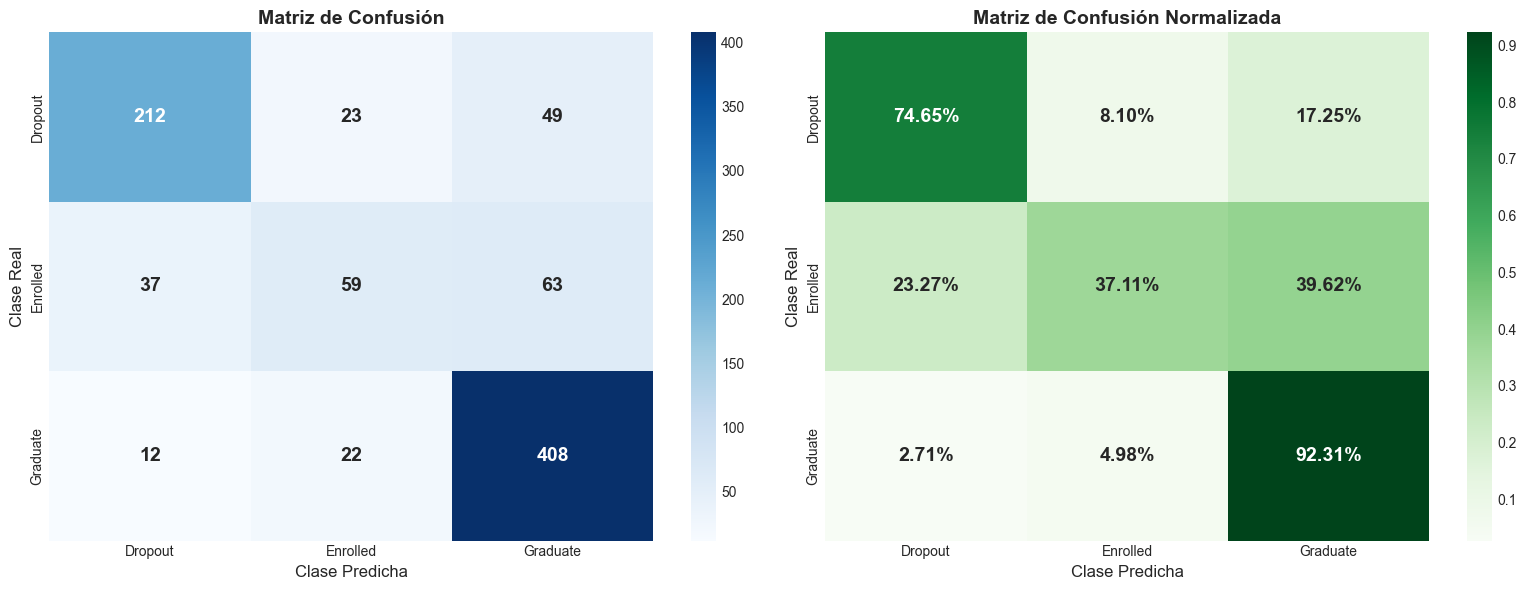

In [42]:
# ============================================================================
# MATRIZ DE CONFUSIÓN
# ============================================================================
cm = confusion_matrix(y_test, y_pred)

print("=" * 80)
print("📊 MATRIZ DE CONFUSIÓN")
print("=" * 80)
print("\nMatriz de confusión (filas = real, columnas = predicho):")
print(cm)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap de la matriz de confusión
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_title('Matriz de Confusión', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Clase Real', fontsize=12)
axes[0].set_xlabel('Clase Predicha', fontsize=12)

# Heatmap normalizado (porcentajes por fila)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2%',
    cmap='Greens',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1],
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[1].set_title('Matriz de Confusión Normalizada', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Clase Real', fontsize=12)
axes[1].set_xlabel('Clase Predicha', fontsize=12)

plt.tight_layout()
plt.show()

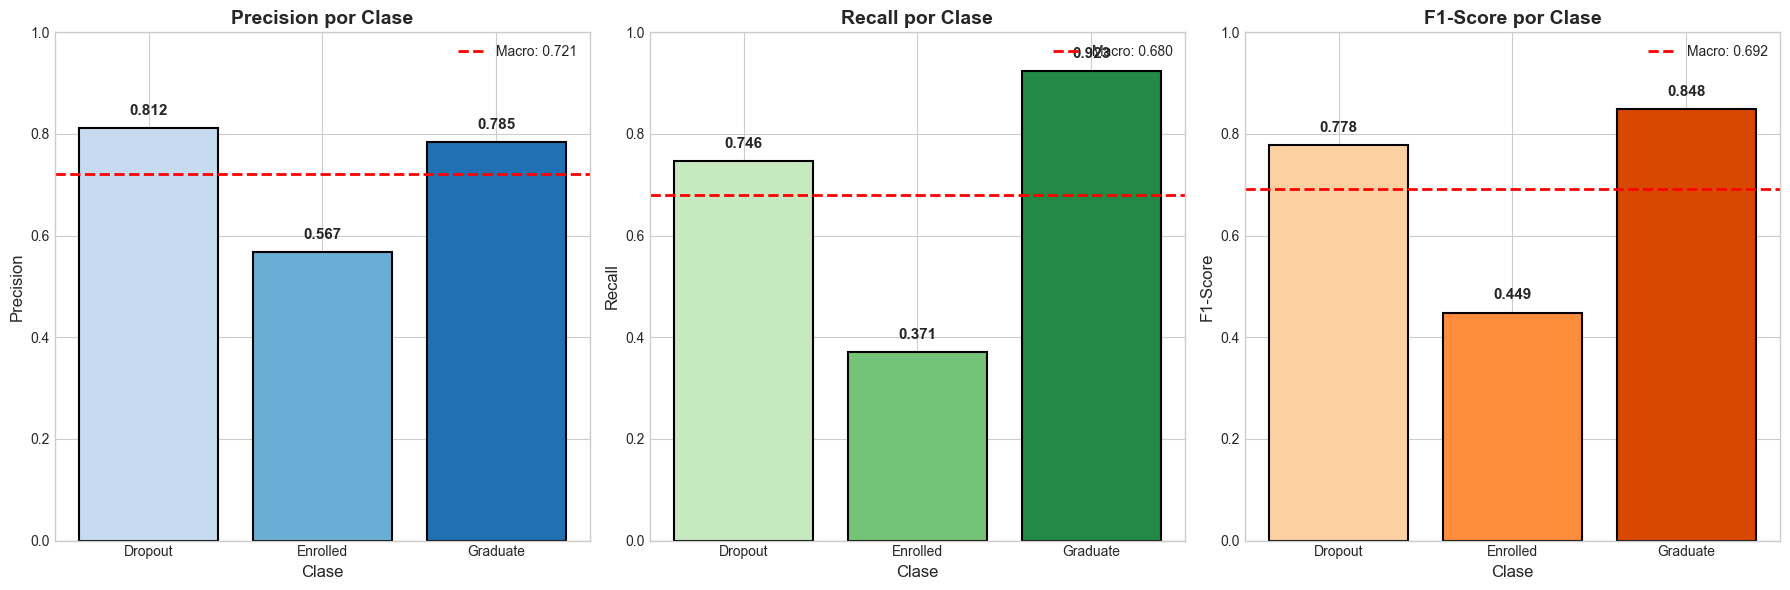

In [43]:
# ============================================================================
# GRÁFICO DE BARRAS DE MÉTRICAS POR CLASE
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Precision por clase
colors_precision = sns.color_palette('Blues', len(class_names))
bars1 = axes[0].bar(class_names, precision_per_class, color=colors_precision, edgecolor='black', linewidth=1.5)
axes[0].set_title('Precision por Clase', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Precision', fontsize=12)
axes[0].set_ylim(0, 1)
axes[0].axhline(y=macro_precision, color='red', linestyle='--', linewidth=2, label=f'Macro: {macro_precision:.3f}')
axes[0].legend()
for bar, val in zip(bars1, precision_per_class):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Recall por clase
colors_recall = sns.color_palette('Greens', len(class_names))
bars2 = axes[1].bar(class_names, recall_per_class, color=colors_recall, edgecolor='black', linewidth=1.5)
axes[1].set_title('Recall por Clase', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=12)
axes[1].set_ylabel('Recall', fontsize=12)
axes[1].set_ylim(0, 1)
axes[1].axhline(y=macro_recall, color='red', linestyle='--', linewidth=2, label=f'Macro: {macro_recall:.3f}')
axes[1].legend()
for bar, val in zip(bars2, recall_per_class):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# F1-Score por clase
colors_f1 = sns.color_palette('Oranges', len(class_names))
bars3 = axes[2].bar(class_names, f1_per_class, color=colors_f1, edgecolor='black', linewidth=1.5)
axes[2].set_title('F1-Score por Clase', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Clase', fontsize=12)
axes[2].set_ylabel('F1-Score', fontsize=12)
axes[2].set_ylim(0, 1)
axes[2].axhline(y=macro_f1, color='red', linestyle='--', linewidth=2, label=f'Macro: {macro_f1:.3f}')
axes[2].legend()
for bar, val in zip(bars3, f1_per_class):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 🎯 9. Importancia de Características

Random Forest permite calcular la importancia de cada característica basándose en cómo contribuyen a reducir la impureza en los árboles de decisión.

In [44]:
# ============================================================================
# CÁLCULO DE IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================================
feature_importance = model.feature_importances_

# Crear DataFrame con la importancia
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
})

# Ordenar por importancia descendente
importance_df = importance_df.sort_values('Importance', ascending=False)

print("=" * 80)
print("📊 IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 80)
print("\nTop 20 características más importantes:")
print(importance_df.head(20).to_string(index=False))

📊 IMPORTANCIA DE CARACTERÍSTICAS

Top 20 características más importantes:
                               Feature  Importance
   Curricular units 2nd sem (approved)    0.142283
      Curricular units 2nd sem (grade)    0.109008
   Curricular units 1st sem (approved)    0.091937
      Curricular units 1st sem (grade)    0.059588
                       Admission grade    0.043575
                     Age at enrollment    0.040287
               Tuition fees up to date    0.038903
Curricular units 2nd sem (evaluations)    0.038200
Curricular units 1st sem (evaluations)    0.037504
        Previous qualification (grade)    0.037498
                                Course    0.033886
                   Father's occupation    0.028781
                   Mother's occupation    0.026213
                                   GDP    0.024465
                     Unemployment rate    0.021617
                      Application mode    0.021541
   Curricular units 2nd sem (enrolled)    0.021081
        

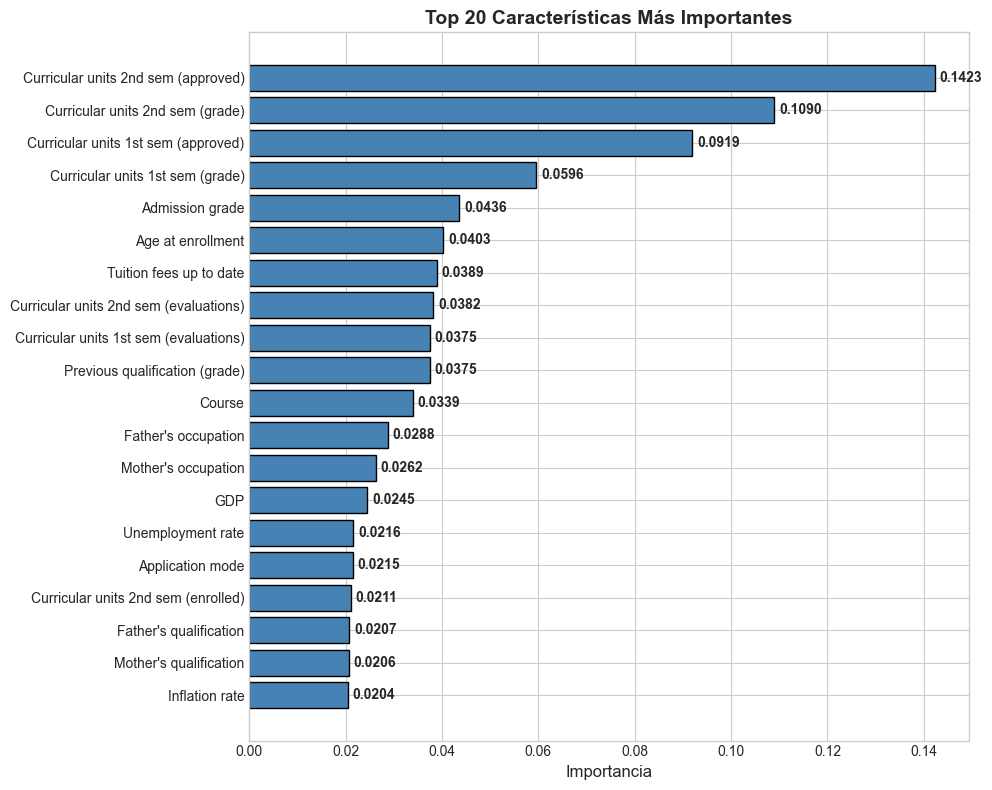

In [45]:
# ============================================================================
# VISUALIZACIÓN DE IMPORTANCIA DE CARACTERÍSTICAS
# ============================================================================
# Top 20 features
top_n = 20
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(range(top_n), top_features['Importance'].values, color='steelblue', edgecolor='black', linewidth=1)
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['Feature'].values, fontsize=10)
ax.invert_yaxis()  # La más importante arriba
ax.set_xlabel('Importancia', fontsize=12)
ax.set_title(f'Top {top_n} Características Más Importantes', fontsize=14, fontweight='bold')

# Añadir valores en las barras
for bar, val in zip(bars, top_features['Importance'].values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 📝 10. Conclusiones

### Resumen del Modelo Random Forest:

1. **Rendimiento General**: El modelo Random Forest ha demostrado su capacidad para predecir el abandono estudiantil.

2. **Métricas Clave**:
   - Accuracy: Indicador del rendimiento global
   - F1-Score: Balance entre precisión y recall
   - Métricas por clase: Rendimiento específico para cada categoría

3. **Características Importantes**: Las variables académicas (notas, unidades curriculares) suelen ser las más predictivas.

4. **Ventajas de Random Forest**:
   - Manejo automático de interacciones entre features
   - Robustez frente a overfitting (comparado con árboles individuales)
   - Importancia de características interpretable
   - No requiere escalado de features

5. **Posibles Mejoras**:
   - Ajuste de hiperparámetros (GridSearch/RandomSearch)
   - Balanceo de clases (SMOTE, class_weight)
   - Feature engineering adicional
   - Validación cruzada para estimación más robusta

In [46]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================
print("=" * 80)
print("📋 RESUMEN FINAL DEL MODELO RANDOM FOREST")
print("=" * 80)
print(f"""
🌲 Modelo: Random Forest Classifier
📊 Dataset: Students Dropout ({len(X)} muestras, {X.shape[1]} features)
🎯 Clases: {class_names}

⚙️ Hiperparámetros:
   - n_estimators: {N_ESTIMATORS}
   - max_depth: {MAX_DEPTH if MAX_DEPTH else 'Sin límite'}
   - min_samples_split: {MIN_SAMPLES_SPLIT}
   - min_samples_leaf: {MIN_SAMPLES_LEAF}
   - random_state: {RANDOM_STATE}

📈 Rendimiento:
   - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
   - Macro F1-Score: {macro_f1:.4f} ({macro_f1*100:.2f}%)
   - Macro Precision: {macro_precision:.4f} ({macro_precision*100:.2f}%)
   - Macro Recall: {macro_recall:.4f} ({macro_recall*100:.2f}%)

🌲 Bosque:
   - Número de árboles: {len(model.estimators_)}
   - Profundidad promedio: {np.mean(depths):.2f}

✅ Modelo entrenado y evaluado exitosamente!
""")

📋 RESUMEN FINAL DEL MODELO RANDOM FOREST

🌲 Modelo: Random Forest Classifier
📊 Dataset: Students Dropout (4424 muestras, 36 features)
🎯 Clases: ['Dropout', 'Enrolled', 'Graduate']

⚙️ Hiperparámetros:
   - n_estimators: 100
   - max_depth: Sin límite
   - min_samples_split: 2
   - min_samples_leaf: 1
   - random_state: 42

📈 Rendimiento:
   - Accuracy: 0.7672 (76.72%)
   - Macro F1-Score: 0.6916 (69.16%)
   - Macro Precision: 0.7214 (72.14%)
   - Macro Recall: 0.6802 (68.02%)

🌲 Bosque:
   - Número de árboles: 100
   - Profundidad promedio: 23.87

✅ Modelo entrenado y evaluado exitosamente!

